## Data preparation & Data Exp.

In [1]:
import pandas as pd

# RAW OKU
df = pd.read_csv("../data/raw/legacy_2004_2018.csv")

# Tarih düzelt
df["TARIH"] = df["TARIH"].str.replace("31.11.", "30.11.", regex=False)
df["TARIH"] = pd.to_datetime(df["TARIH"], format="mixed", dayfirst=True)

# Sadece gerekli kolonları seç
df = df[[
    "TARIH",
    "TUIK Tüketici Güven endeksi",
    "USD Kur",
    "Reel Döviz Kuru",
    "BIST Getiri (TL)",
    "İmalat Kapasite Kullanım Oranı",
    "İşsizlik Oranı",
    "Enflasyon Oranı",
    "Sanayi Üretim Endeksi"
]]

# Kolonları yeniden adlandır (temiz isimler)
df.columns = [
    "date",
    "tge",
    "usd",
    "reel_kur",
    "bist",
    "ikko",
    "issizlik",
    "enflasyon",
    "sue"
]

# Index yap
df = df.set_index("date").sort_index()

df.head()

,tge,usd,reel_kur,bist,ikko,issizlik,enflasyon,sue
date,,,,,,,,
2001-12-28,NaN,"1,4396","123,73","15332,15","73,30","8,4","3,2","89,40"
2002-01-31,NaN,"1,3208","87,09","14742,08","73,90","8,4","5,3","91,20"
2002-02-28,NaN,"1,3993","97,57","12298,49","71,00","8,4","1,8","85,80"
2002-03-29,NaN,"1,3325","101,69","12992,37","75,30","8,4","1,2","104,40"
2002-04-30,NaN,"1,3315","103,64","12789,71","73,80","8,4","2,1","103,50"


## Data Info

In [2]:
def clean_numeric(series):
    return (
        series.astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(".", "", regex=False)      # binlik ayırıcıyı kaldır
        .str.replace(",", ".", regex=False)     # ondalık düzelt
        .astype(float)
    )

for col in df.columns:
    df[col] = clean_numeric(df[col])

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 205 entries, 2001-12-28 to 2018-12-31
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   tge        180 non-null    float64
 1   usd        205 non-null    float64
 2   reel_kur   205 non-null    float64
 3   bist       205 non-null    float64
 4   ikko       205 non-null    float64
 5   issizlik   205 non-null    float64
 6   enflasyon  205 non-null    float64
 7   sue        205 non-null    float64
dtypes: float64(8)
memory usage: 14.4 KB


In [3]:
df = df.loc["2004-01-01":]
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 180 entries, 2004-01-30 to 2018-12-31
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   tge        180 non-null    float64
 1   usd        180 non-null    float64
 2   reel_kur   180 non-null    float64
 3   bist       180 non-null    float64
 4   ikko       180 non-null    float64
 5   issizlik   180 non-null    float64
 6   enflasyon  180 non-null    float64
 7   sue        180 non-null    float64
dtypes: float64(8)
memory usage: 12.7 KB


In [4]:
df = df.loc["2004-01-01":]

## ADF tests

In [5]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test: {name}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("-" * 40)

for col in df.columns:
    adf_test(df[col], col)

ADF Test: tge
ADF Statistic: -2.0110664426274596
p-value: 0.28174202897720163
----------------------------------------
ADF Test: usd
ADF Statistic: 4.402389990332068
p-value: 1.0
----------------------------------------
ADF Test: reel_kur
ADF Statistic: -0.43894258566934224
p-value: 0.9033909149112561
----------------------------------------
ADF Test: bist
ADF Statistic: -0.8385942224849473
p-value: 0.8075216772146313
----------------------------------------
ADF Test: ikko
ADF Statistic: -1.9905224207493222
p-value: 0.2907440865505934
----------------------------------------
ADF Test: issizlik
ADF Statistic: -2.442446667220814
p-value: 0.13011267340250993
----------------------------------------
ADF Test: enflasyon
ADF Statistic: -2.320880322815741
p-value: 0.16532205430366276
----------------------------------------
ADF Test: sue
ADF Statistic: -2.981094895179597
p-value: 0.03669801515099186
----------------------------------------


In [6]:
df_diff = df.copy()

for col in df_diff.columns:
    df_diff[col] = df_diff[col].pct_change()

df_diff = df_diff.dropna()

df_diff.head()

,tge,usd,reel_kur,bist,ikko,issizlik,enflasyon,sue
date,,,,,,,,
2004-02-27,0.005092,-0.006976,0.046756,0.094439,-0.047927,0.019417,-0.212121,-0.087344
2004-03-31,-0.009119,-0.009517,0.012829,0.072324,0.117007,0.000000,0.846154,0.226562
2004-04-30,0.000000,0.098223,0.032082,-0.101406,-0.068210,0.000000,-0.489583,-0.027070
2004-05-31,-0.038855,0.031387,-0.013437,-0.047618,0.101961,0.000000,-0.102041,0.060556
2004-06-30,-0.006383,0.000404,-0.095069,0.056138,0.011862,0.000000,-1.318182,0.010802


In [7]:
for col in df_diff.columns:
    adf_test(df_diff[col], col)

ADF Test: tge
ADF Statistic: -4.142913828432103
p-value: 0.0008218785130310889
----------------------------------------
ADF Test: usd
ADF Statistic: -9.75450682967546
p-value: 7.854749572528761e-17
----------------------------------------
ADF Test: reel_kur
ADF Statistic: -7.417714906308467
p-value: 6.865160631506382e-11
----------------------------------------
ADF Test: bist
ADF Statistic: -4.705922794797034
p-value: 8.202311210446113e-05
----------------------------------------
ADF Test: ikko
ADF Statistic: -1.9286833652453843
p-value: 0.3186901624675591
----------------------------------------
ADF Test: issizlik
ADF Statistic: -3.2350047646250752
p-value: 0.018045797922012954
----------------------------------------
ADF Test: enflasyon
ADF Statistic: -13.315953672932762
p-value: 6.602694679578445e-25
----------------------------------------
ADF Test: sue
ADF Statistic: -4.0035962749929075
p-value: 0.0013917967313680074
----------------------------------------


In [8]:
import numpy as np

df_ld = df.copy()
df_ld["ikko"] = np.log(df["ikko"]).diff()


for col in df_ld.columns:
    if col != "ikko":
        df_ld[col] = df_ld[col].pct_change()

df_ld = df_ld.dropna()

In [9]:
adf_test(df_ld["ikko"], "ikko_logdiff")

ADF Test: ikko_logdiff
ADF Statistic: -1.9020680009536306
p-value: 0.33108888407999415
----------------------------------------


## VAR model

In [10]:
df_var = df_diff.drop(columns=["ikko"])
df_var.head()

,tge,usd,reel_kur,bist,issizlik,enflasyon,sue
date,,,,,,,
2004-02-27,0.005092,-0.006976,0.046756,0.094439,0.019417,-0.212121,-0.087344
2004-03-31,-0.009119,-0.009517,0.012829,0.072324,0.000000,0.846154,0.226562
2004-04-30,0.000000,0.098223,0.032082,-0.101406,0.000000,-0.489583,-0.027070
2004-05-31,-0.038855,0.031387,-0.013437,-0.047618,0.000000,-0.102041,0.060556
2004-06-30,-0.006383,0.000404,-0.095069,0.056138,0.000000,-1.318182,0.010802


In [11]:
from statsmodels.tsa.api import VAR

model = VAR(df_var)
lag_results = model.select_order(12)
lag_results.summary()

c:\Users\LenovoTuncay\Documents\financial_time_series_modernization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-32.79,-32.66*,5.759e-15,-32.73
1,-33.43,-32.39,3.020e-15,-33.01*
2,-33.49,-31.53,2.859e-15,-32.70
3,-33.57,-30.70,2.662e-15*,-32.40
4,-33.28,-29.49,3.622e-15,-31.74
5,-33.10,-28.39,4.428e-15,-31.19
6,-33.01,-27.39,5.032e-15,-30.73
7,-32.78,-26.25,6.607e-15,-30.13
8,-32.62,-25.17,8.359e-15,-29.59
9,-32.66,-24.30,8.712e-15,-29.27


In [12]:
var_model = model.fit(3)
var_model.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 04, Mar, 2026
Time:                     13:02:47
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                   -30.7257
Nobs:                     176.000    HQIC:                  -32.3747
Log likelihood:           1353.86    FPE:                2.85216e-15
AIC:                     -33.4999    Det(Omega_mle):     1.25057e-15
--------------------------------------------------------------------
Results for equation tge
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const               -0.002373         0.003672           -0.646           0.518
L1.tge               0.067557         0.084007            0.804           0.421
L1.usd              -0.228203         0.091081           -2.505   

In [13]:
var_model.is_stable()

np.True_

In [14]:
var_model.test_causality("tge", ["usd"], kind="f")

## Granger causality

In [15]:
granger_result = var_model.test_causality("tge", ["usd"], kind="f")
print(granger_result.summary())

Granger causality F-test. H_0: usd does not Granger-cause tge. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
         2.520          2.613   0.057 (3, 1078)
-----------------------------------------------


In [16]:
for col in var_model.model.endog_names:
    if col != "tge":
        result = var_model.test_causality("tge", [col], kind="f")
        print(col, result.pvalue)

usd 0.056583366303547
reel_kur 0.5204699827191757
bist 0.7354188008259451
issizlik 0.7837377280969858
enflasyon 0.22140355825729627
sue 0.9537408976117381


## IRF (Impulse Response Function)

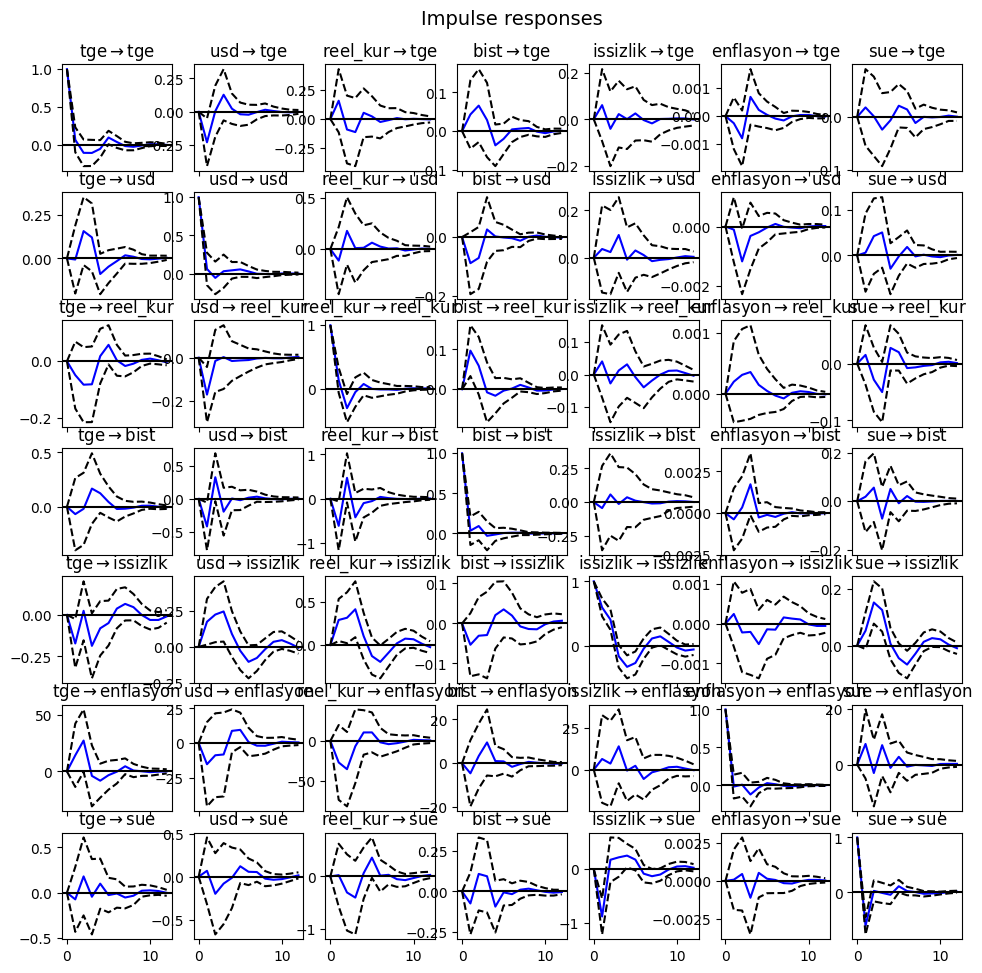

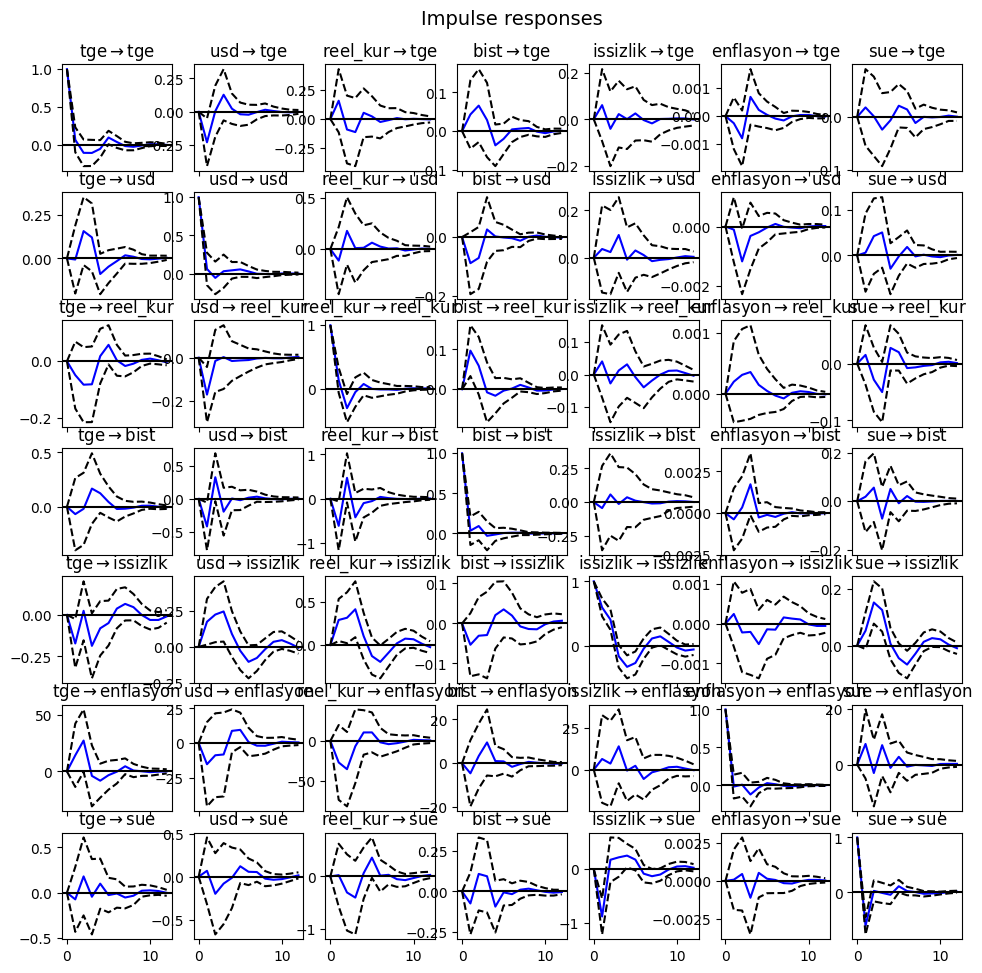

In [17]:
irf = var_model.irf(12)
irf.plot(orth=False)

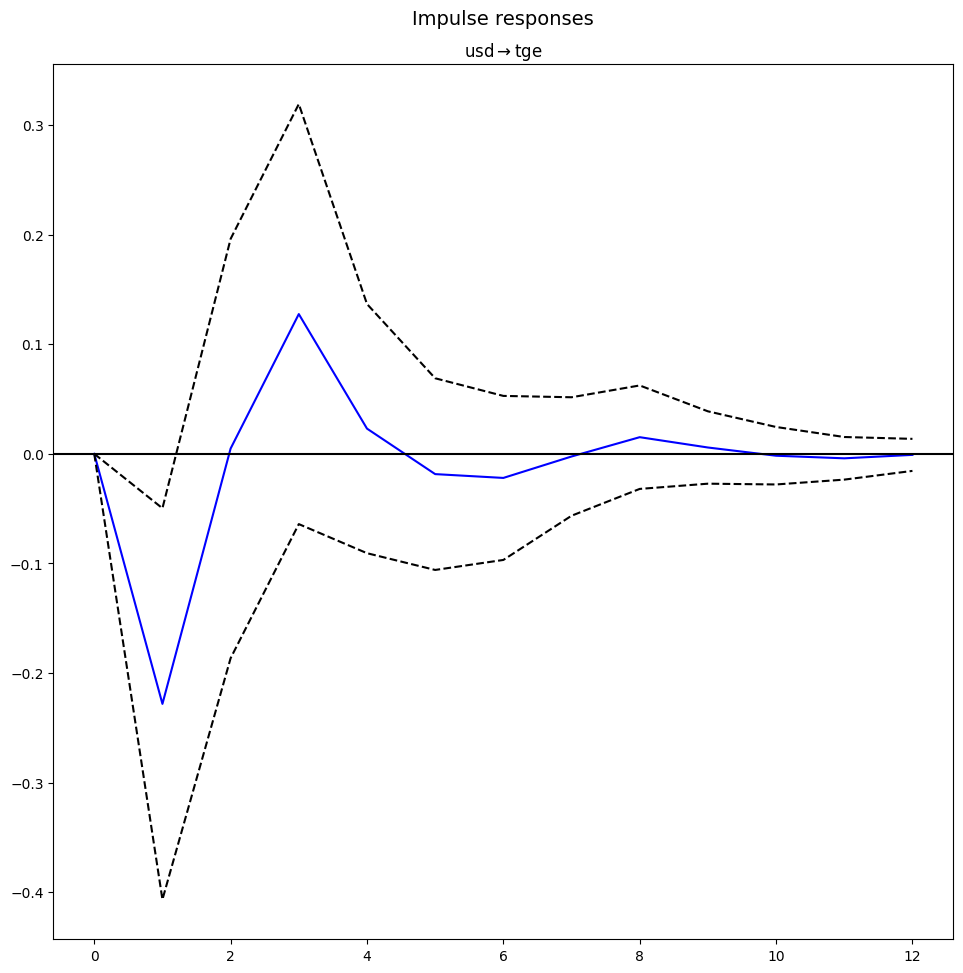

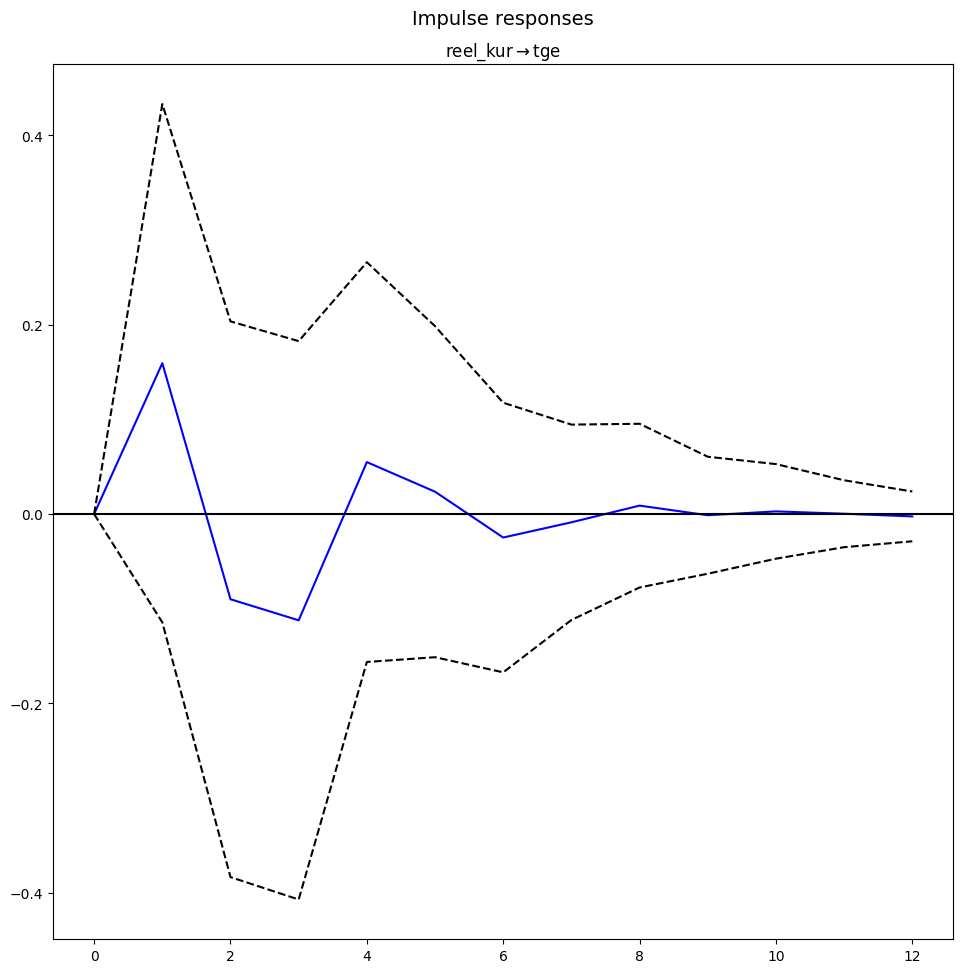

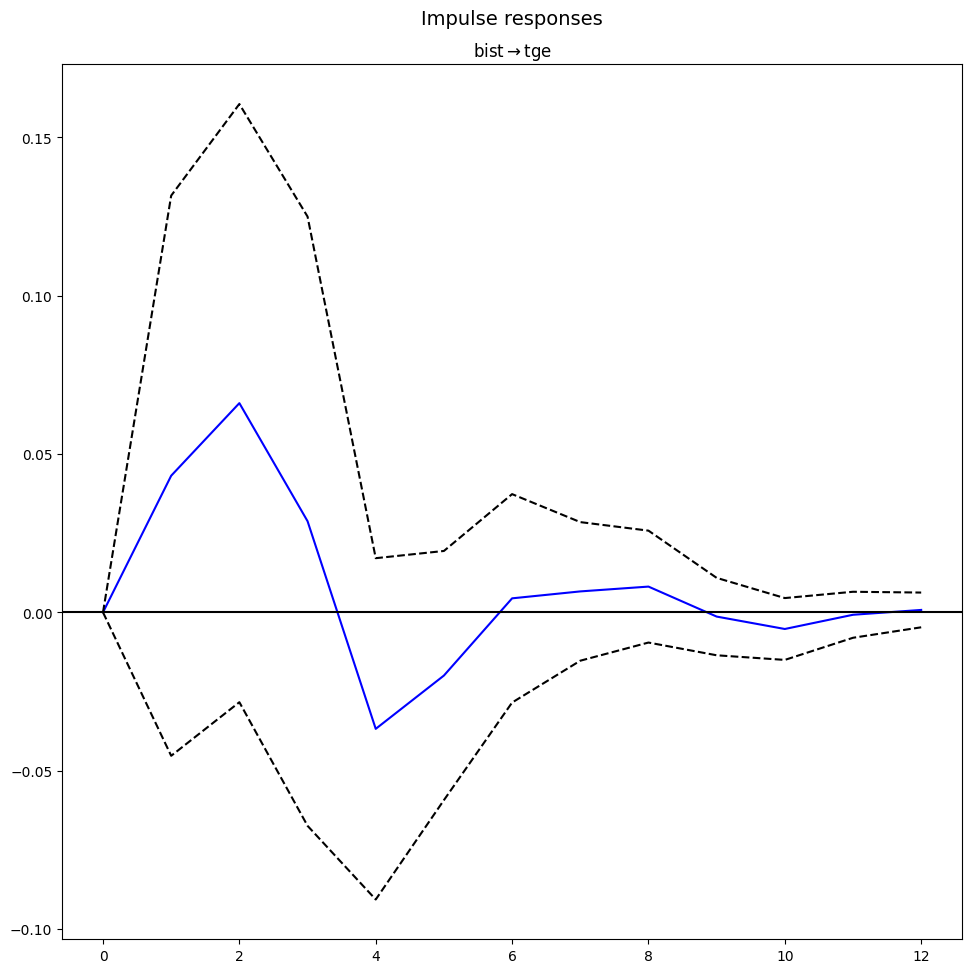

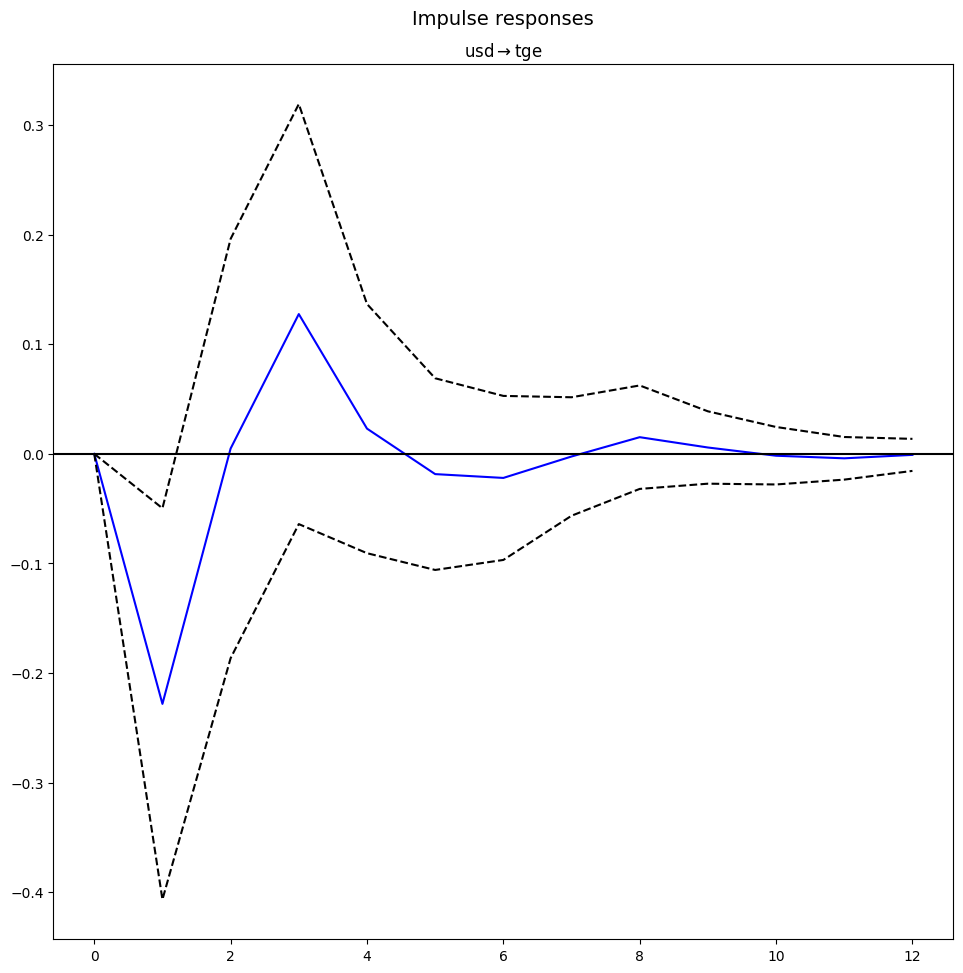

In [18]:
irf.plot(impulse="reel_kur", response="tge")
irf.plot(impulse="bist", response="tge")
irf.plot(impulse="usd", response="tge")

## FEVD (Forecast Error Variance Decomposition)

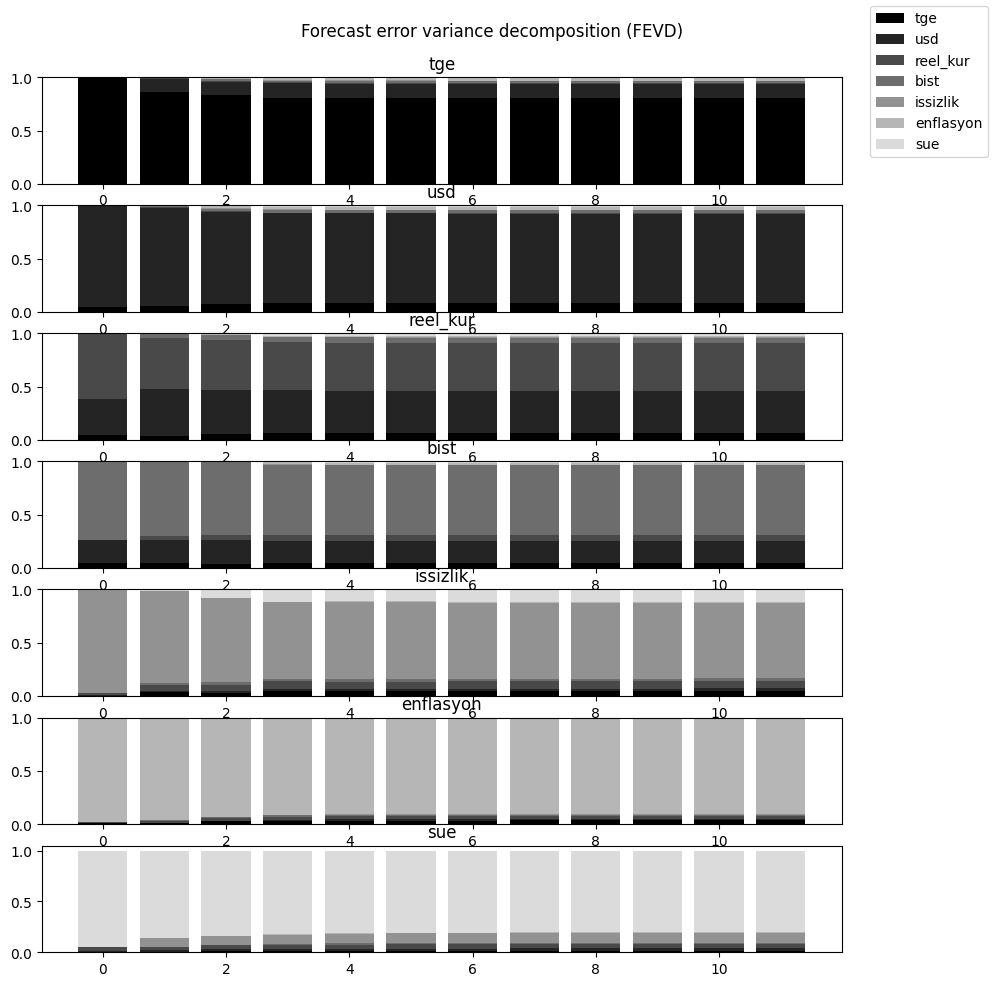

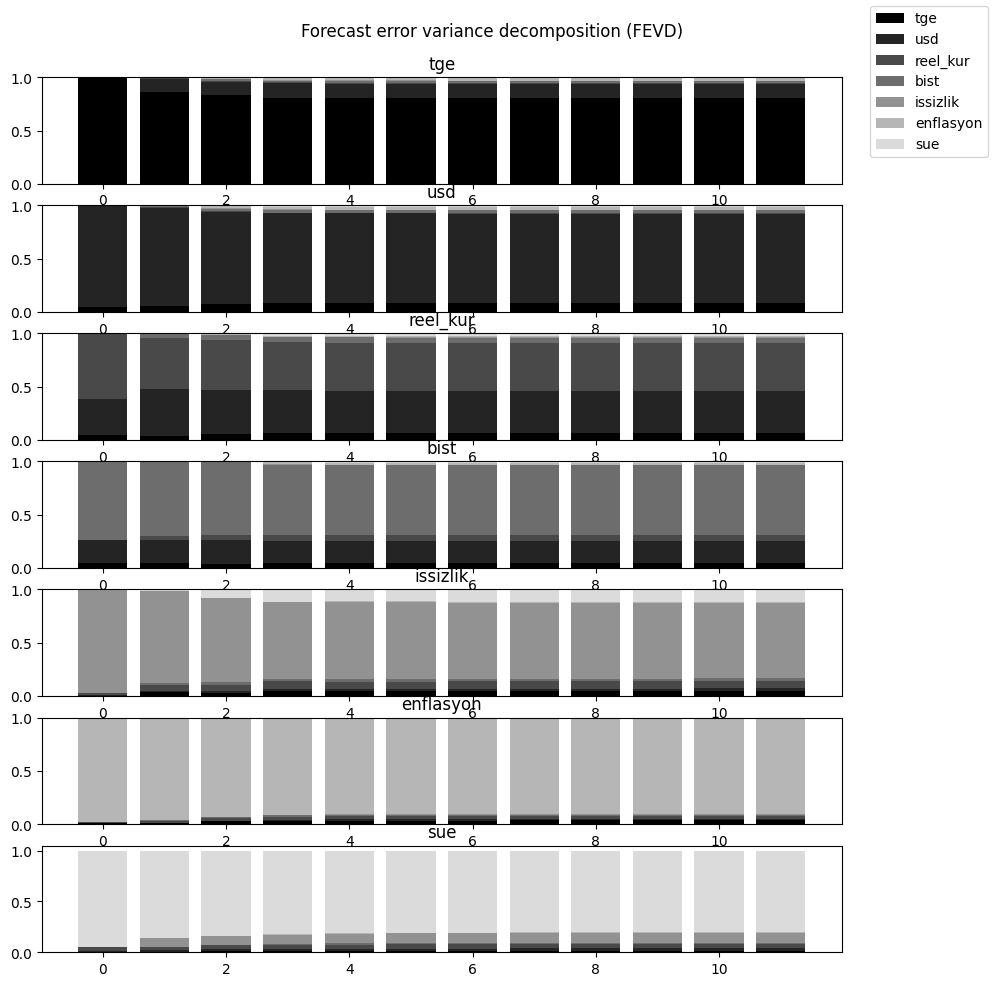

In [19]:
fevd = var_model.fevd(12)
fevd.plot()

In [20]:
fevd.summary()

FEVD for tge
           tge       usd  reel_kur      bist  issizlik  enflasyon       sue
0     1.000000  0.000000  0.000000  0.000000  0.000000   0.000000  0.000000
1     0.863543  0.120784  0.006741  0.004035  0.002286   0.001434  0.001178
2     0.838128  0.116781  0.009715  0.015040  0.003405   0.015791  0.001140
3     0.809729  0.132702  0.010181  0.016021  0.003584   0.024707  0.003077
4     0.805354  0.132564  0.010963  0.018897  0.003550   0.025482  0.003191
5     0.804156  0.131443  0.010878  0.019745  0.003877   0.025280  0.004620
6     0.803216  0.131395  0.011192  0.019723  0.003874   0.025349  0.005250
7     0.802160  0.131211  0.011187  0.019828  0.004054   0.025862  0.005699
8     0.802084  0.131156  0.011205  0.019960  0.004052   0.025847  0.005695
9     0.802023  0.131186  0.011203  0.019961  0.004054   0.025873  0.005699
10    0.801939  0.131167  0.011206  0.020023  0.004064   0.025904  0.005698
11    0.801914  0.131171  0.011205  0.020023  0.004071   0.025901  0.005714

## Residual Diagnostics

To evaluate the adequacy of the VAR model, several residual diagnostic tests were conducted. These include serial correlation tests, normality tests, and whiteness tests.

In [21]:
# Residual whiteness test (serial correlation check)
print(var_model.test_whiteness())

# Residual normality test
print(var_model.test_normality())

<statsmodels.tsa.vector_ar.hypothesis_test_results.WhitenessTestResults object. H_0: residual autocorrelation up to lag 10 is zero: fail to reject at 5% significance level. Test statistic: 325.244, critical value: 387.188>, p-value: 0.747>
<statsmodels.tsa.vector_ar.hypothesis_test_results.NormalityTestResults object. H_0: data generated by normally-distributed process: reject at 5% significance level. Test statistic: 7933.554, critical value: 23.685>, p-value: 0.000>


### Residual diagnostics

In [22]:
wt = var_model.test_whiteness(nlags=10)
nt = var_model.test_normality()

print(wt.summary())
print(nt.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value  df
-----------------------------------------
         325.2          387.2   0.747 343
-----------------------------------------
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         7934.          23.68   0.000 14
----------------------------------------


### Residual autocorrelation görselleştirme

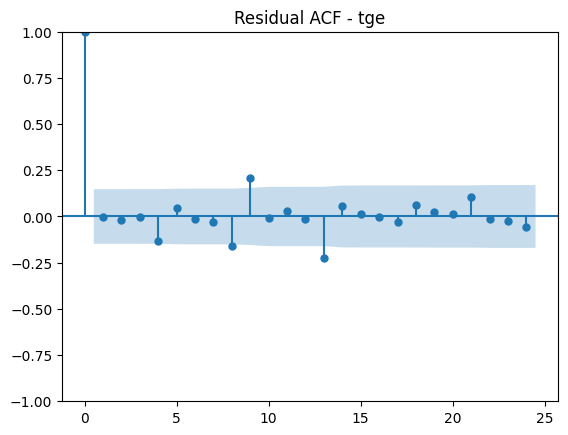

In [24]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

resid = var_model.resid  # DataFrame: residuals

fig = plot_acf(resid["tge"].dropna(), lags=24)
plt.title("Residual ACF - tge")
plt.show()

### Residual normality görselleştirme

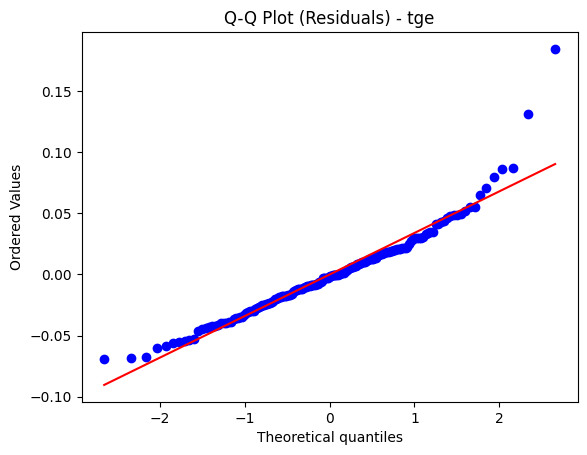

In [25]:
import scipy.stats as stats
import matplotlib.pyplot as plt

x = resid["tge"].dropna()
stats.probplot(x, dist="norm", plot=plt)
plt.title("Q-Q Plot (Residuals) - tge")
plt.show()

## Key Findings

Consumer confidence dynamics are primarily driven by its own shocks, explaining approximately **80% of the forecast error variance**.

Exchange rate shocks account for roughly **13% of consumer confidence variability**, indicating a moderate influence.

Impulse response analysis suggests that macroeconomic shocks **dissipate within approximately 6–8 periods**, implying that shocks do not create long-lasting instability in the system.

Residual diagnostics confirm the **adequacy of the VAR model**, with no significant residual autocorrelation detected.

---

## Model Sonuçlarının Genel Değerlendirmesi

Bu çalışmada tüketici güven endeksi (TGE) ile çeşitli makroekonomik değişkenler arasındaki dinamik ilişkiler **Vector Autoregression (VAR)** modeli kullanılarak incelenmiştir. 

Analiz kapsamında aşağıdaki yöntemler uygulanmıştır:

- Granger nedensellik testleri  
- Impulse Response Function (IRF) analizi  
- Forecast Error Variance Decomposition (FEVD)  
- Model artıklarına yönelik tanı testleri (Residual Diagnostics)

Elde edilen bulgular tüketici güveninin büyük ölçüde kendi iç dinamikleri tarafından şekillendiğini, makroekonomik şokların ise sınırlı fakat ölçülebilir etkiler yarattığını göstermektedir.

---

## Temel Bulgular

### Tüketici güveni büyük ölçüde kendi dinamiklerinden etkilenmektedir

FEVD sonuçlarına göre tüketici güven endeksinin tahmin hatası varyansının yaklaşık **%80’i kendi şokları tarafından açıklanmaktadır**. Bu bulgu tüketici güveninin geçmiş değerleri ve beklenti dinamikleri tarafından güçlü şekilde belirlendiğini göstermektedir.

### Döviz kuru etkisi sınırlı fakat anlamlıdır

Analiz sonuçlarına göre döviz kuru şokları tüketici güvenindeki varyansın yaklaşık **%13’ünü açıklamaktadır**. Bu durum döviz kuru hareketlerinin tüketici beklentileri üzerinde belirli bir etkiye sahip olduğunu ancak ana belirleyici olmadığını göstermektedir.

### Makroekonomik şoklar kısa sürede sönümlenmektedir

Impulse Response Function (IRF) sonuçları sistemde oluşan şokların etkisinin genellikle **6–8 dönem içerisinde ortadan kalktığını** göstermektedir. Bu durum sistemin zaman içinde yeniden dengeye döndüğünü ve modelde patlayıcı dinamiklerin bulunmadığını göstermektedir.

---

# Residual Diagnostics

VAR modelinin istatistiksel geçerliliğini değerlendirmek amacıyla model artıklarına yönelik tanı testleri uygulanmıştır. Bu testler model varsayımlarının sağlanıp sağlanmadığını incelemek için kullanılmaktadır.

Uygulanan başlıca testler:

- **Whiteness (Portmanteau) testi:** Artıklarda seri korelasyon olup olmadığını kontrol eder  
- **Normality testi:** Artıkların normal dağılıma sahip olup olmadığını inceler  
- **Grafiksel inceleme:** ACF ve Q-Q grafikleri ile artık davranışı görselleştirilmiştir

---

## Serial Correlation (Whiteness Test)

Portmanteau whiteness testi sonuçlarına göre:

- **p-value = 0.747**

Bu değer %5 anlamlılık düzeyinden büyük olduğu için **boş hipotez reddedilememektedir**.

Boş hipotez:

> Artıklar belirli bir gecikmeye kadar seri korelasyon içermemektedir.

Dolayısıyla elde edilen sonuçlar **model artıklarında anlamlı bir seri korelasyon bulunmadığını** göstermektedir. Başka bir ifadeyle artıkların **white noise özellikleri gösterdiği** söylenebilir.

Bu durum VAR modelinin önemli varsayımlarından birinin sağlandığını göstermektedir.

---

## Normality Test

Normalite testine göre:

- **p-value ≈ 0.000**

Bu durumda artıkların normal dağıldığı yönündeki boş hipotez reddedilmektedir.

Ancak makroekonomik zaman serilerinde artıkların tam olarak normal dağılıma uymaması oldukça yaygın bir durumdur. Bunun başlıca nedenleri şunlardır:

- ekonomik krizler ve yapısal kırılmalar  
- volatilite kümelenmesi  
- doğrusal olmayan ekonomik dinamikler  

Bu nedenle normallik varsayımının ihlal edilmesi çoğu makroekonomik çalışmada gözlenen bir durumdur ve genellikle modelin tamamen geçersiz olduğu anlamına gelmez.

---

## Graphical Diagnostics (ACF & Q–Q Plot)

Artıkların davranışı grafiksel olarak da incelenmiştir.

**ACF grafiği**

- Gecikmelerin büyük bölümü güven aralığı içinde kalmaktadır.
- Bu durum artıkların belirgin bir seri korelasyon yapısı taşımadığını göstermektedir.

**Q-Q grafiği**

- Grafikte özellikle uç değerlerde normal dağılımdan sapmalar görülmektedir.
- Bu durum makroekonomik verilerde sık gözlenen kalın kuyruk (fat tail) davranışıyla uyumludur.

---

## Model Tanı Testlerinin Özeti

| Test | Sonuç |
|-----|------|
| Serial Correlation | ✔ Yok |
| Model Stability | ✔ Sağlandı |
| Impulse Response | ✔ Stabil |
| FEVD | ✔ Ekonomik olarak anlamlı |

Bu sonuçlar VAR modelinin genel olarak **istikrarlı ve yorumlanabilir bir yapı sunduğunu** göstermektedir.

---

# Genel Değerlendirme

Bu çalışmadan elde edilen bulgular aşağıdaki temel çıkarımları ortaya koymaktadır:

- Tüketici güven endeksi büyük ölçüde **kendi iç dinamikleri tarafından belirlenmektedir**.
- Döviz kuru şokları tüketici güveni üzerinde **sınırlı fakat ölçülebilir bir etkiye sahiptir**.
- Makroekonomik şokların etkisi genellikle **kısa süreli olup birkaç dönem içerisinde sönümlenmektedir**.
- Model tanı testleri VAR modelinin genel olarak **uygun bir spesifikasyona sahip olduğunu** göstermektedir.

Bu bulgular tüketici güveninin makroekonomik değişkenlerden tamamen bağımsız olmadığını ancak büyük ölçüde **beklenti ve davranışsal dinamikler tarafından şekillenen bir gösterge** olduğunu ortaya koymaktadır.

## Conclusion

Bu çalışmada tüketici güven endeksi ile çeşitli makroekonomik değişkenler arasındaki dinamik ilişkiler **Vector Autoregression (VAR)** modeli kullanılarak incelenmiştir. Yapılan analizler tüketici güveninin büyük ölçüde kendi iç dinamikleri tarafından belirlendiğini, makroekonomik değişkenlerin ise sınırlı fakat ölçülebilir etkiler yarattığını göstermektedir.

Impulse Response Function (IRF) sonuçları makroekonomik şokların etkisinin genellikle kısa süreli olduğunu ve sistemin yaklaşık **6–8 dönem içerisinde yeniden dengeye döndüğünü** ortaya koymaktadır. Forecast Error Variance Decomposition (FEVD) sonuçları ise tüketici güveninin varyansının büyük bölümünün kendi inovasyonlarından kaynaklandığını, döviz kuru şoklarının ise ikincil fakat anlamlı bir rol oynadığını göstermektedir.

Model tanı testleri VAR modelinin genel olarak **istikrarlı ve uygun bir spesifikasyona sahip olduğunu** göstermektedir. Artıklarda anlamlı bir seri korelasyon bulunmazken, normallik varsayımındaki sapmalar makroekonomik zaman serilerinde sık görülen bir durum olarak değerlendirilmiştir.

Gelecek çalışmalar için veri setinin daha güncel dönemleri kapsayacak şekilde genişletilmesi, değişkenler arasında **eşbütünleşme (cointegration)** ilişkilerinin test edilmesi ve gerekli durumlarda **Vector Error Correction Model (VECM)** yaklaşımının uygulanması daha zengin sonuçlar sağlayabilir. Ayrıca makroekonomik dinamiklerin doğrusal olmayan özelliklerini incelemek amacıyla alternatif zaman serisi modelleri de değerlendirilebilir.